<a href="https://colab.research.google.com/github/Yaswanth-k-REDDY/ML-Internship-Tasks/blob/main/Task2_EDA_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Download complete.
   Survived  Pclass                                               Name  \
0         0       3                             Mr. Owen Harris Braund   
1         1       1  Mrs. John Bradley (Florence Briggs Thayer) Cum...   
2         1       3                              Miss. Laina Heikkinen   
3         1       1        Mrs. Jacques Heath (Lily May Peel) Futrelle   
4         0       3                            Mr. William Henry Allen   

      Sex   Age  Siblings/Spouses Aboard  Parents/Children Aboard     Fare  
0    male  22.0                        1                        0   7.2500  
1  female  38.0                        1                        0  71.2833  
2  female  26.0                        0                        0   7.9250  
3  female  35.0                        1                        0  53.1000  
4    male  35.0                        0                        0   8.0500  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Da

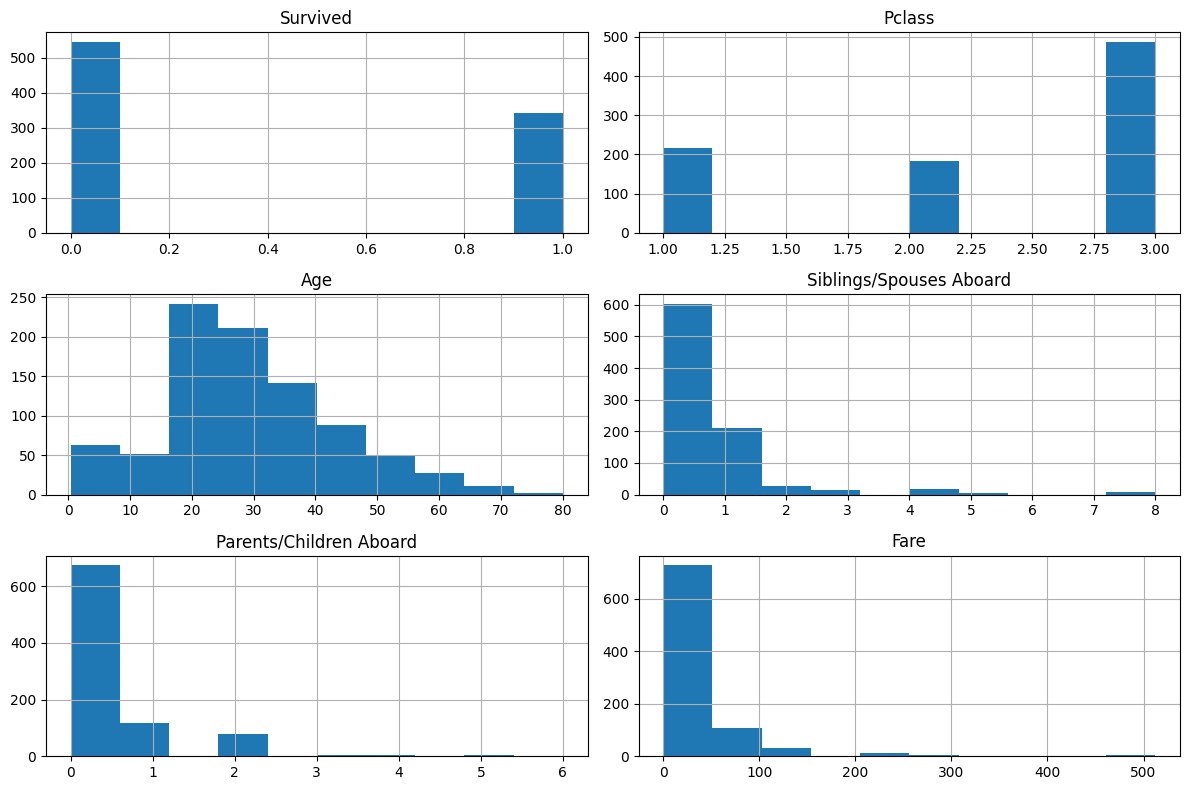

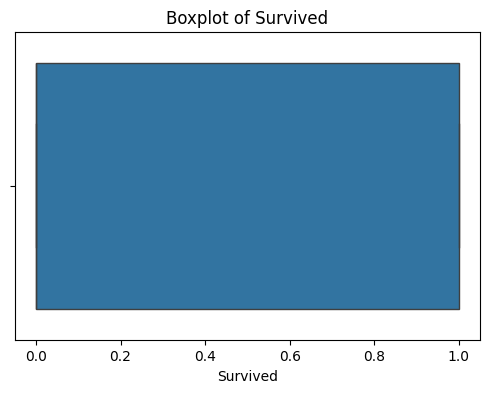

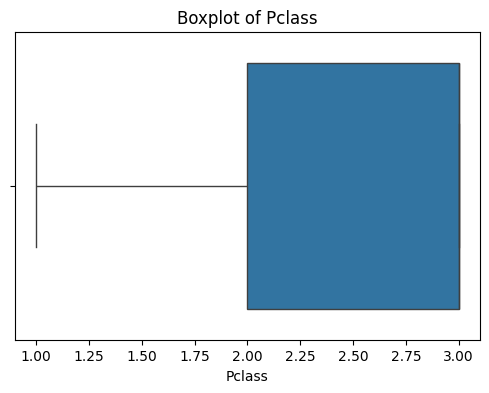

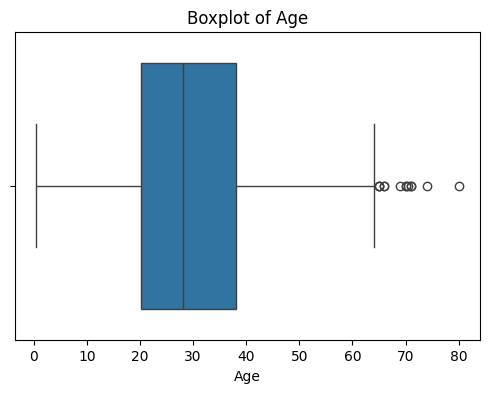

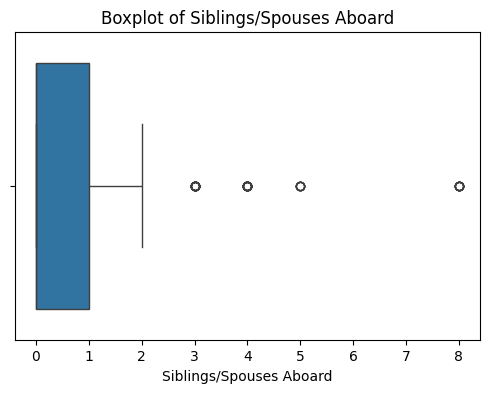

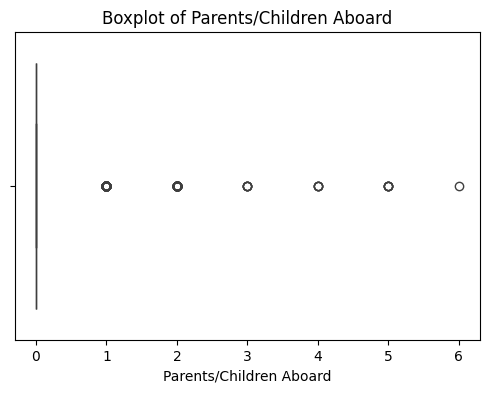

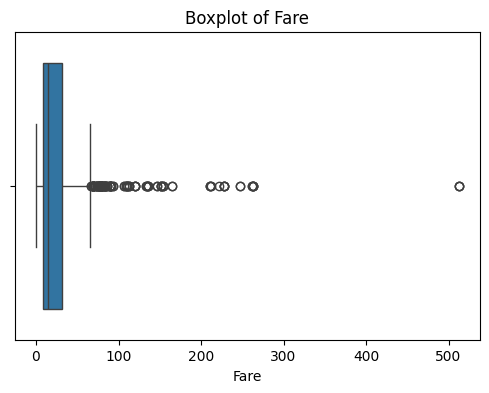

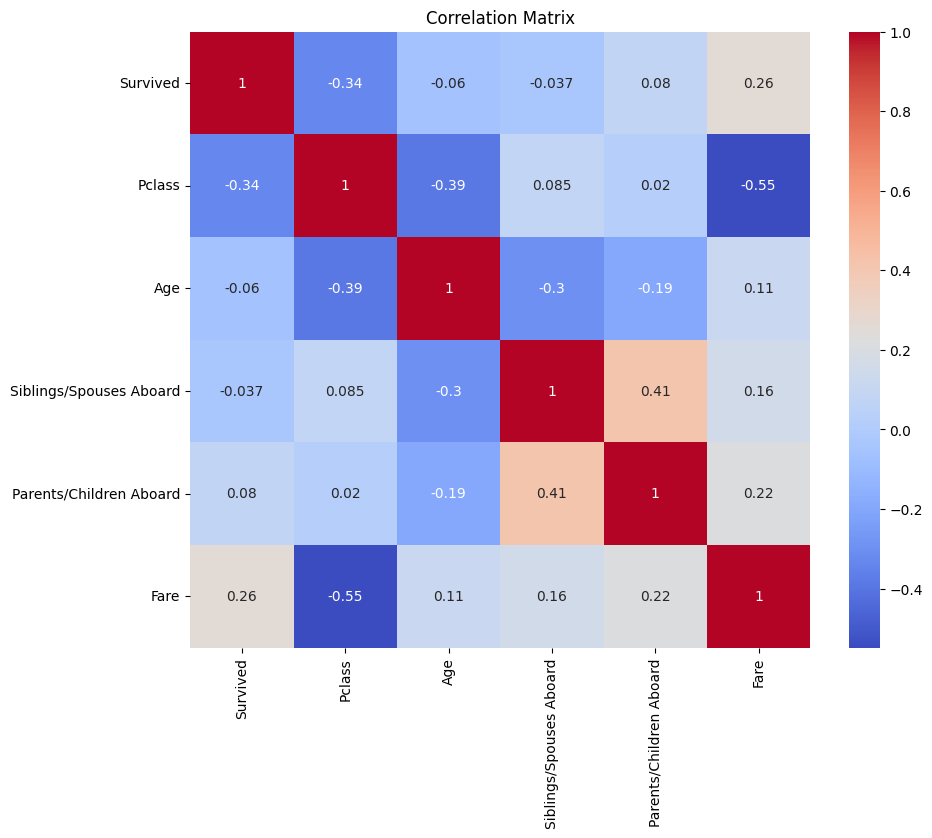

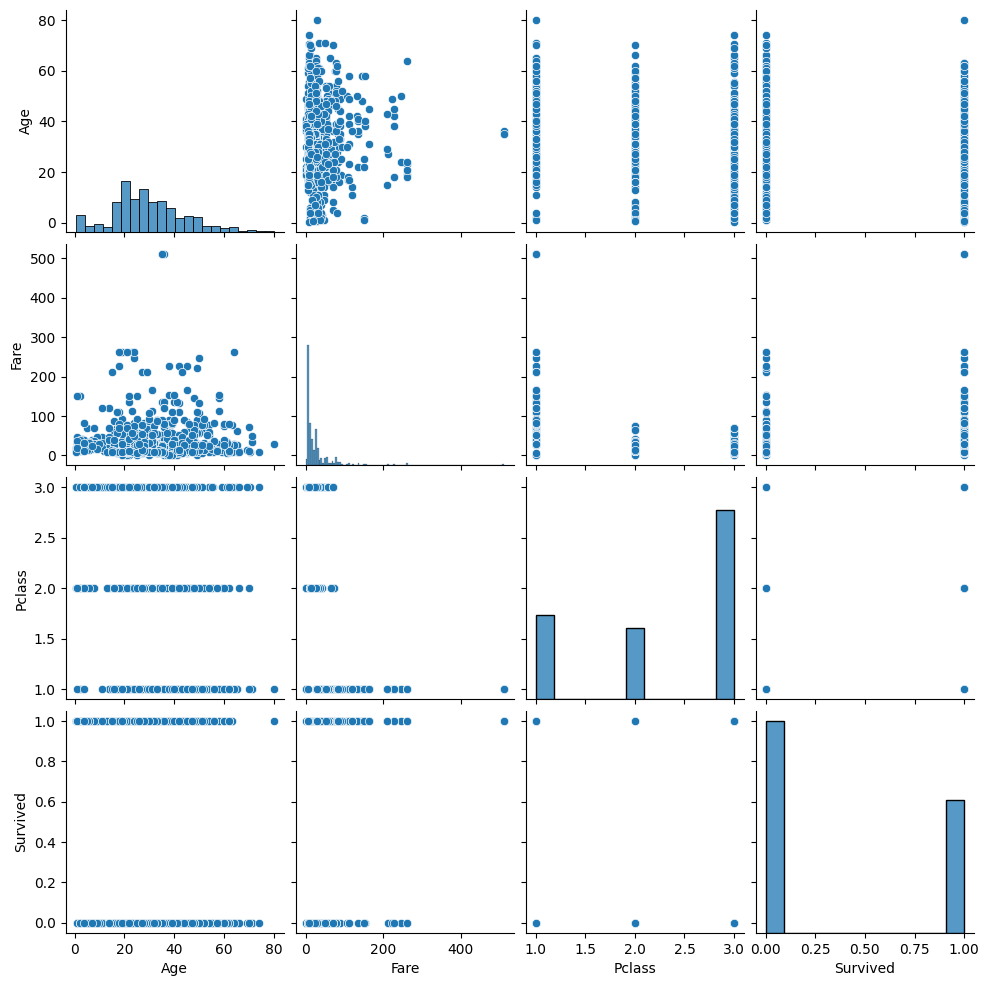

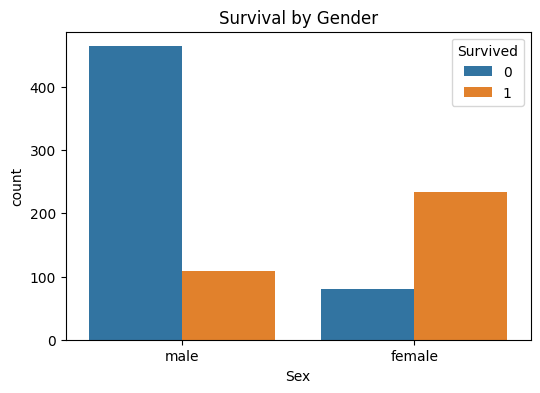

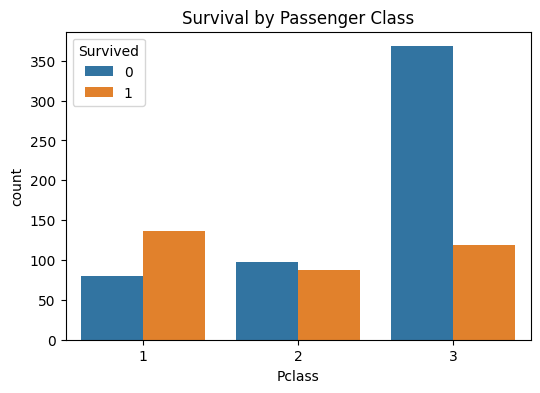


Skewness:
Survived                   0.470999
Pclass                    -0.623409
Age                        0.447189
Siblings/Spouses Aboard    3.686760
Parents/Children Aboard    2.741198
Fare                       4.777671
dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define the URL and filename for the dataset
DATA_URL = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"
FILE_NAME = "Titanic.csv"

# Load Dataset
# Check if the file exists, if not, download it
if not os.path.exists(FILE_NAME):
    print(f"Downloading {FILE_NAME}...")
    pd.read_csv(DATA_URL).to_csv(FILE_NAME, index=False)
    print("Download complete.")
df = pd.read_csv(FILE_NAME)

# Display basic information
print(df.head())
print(df.info())
print(df.shape)

# Summary Statistics
print(df.describe())
print(df.median(numeric_only=True))

# Missing Values
print(df.isnull().sum())

# Histograms
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

# Boxplots for Numeric Columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Pairplot
selected_cols = [col for col in ['Age', 'Fare', 'Pclass', 'Survived'] if col in df.columns]
sns.pairplot(df[selected_cols].dropna())
plt.show()

# Survival Analysis by Gender
if 'Sex' in df.columns and 'Survived' in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(x='Sex', hue='Survived', data=df)
    plt.title("Survival by Gender")
    plt.show()

# Survival Analysis by Passenger Class
if 'Pclass' in df.columns and 'Survived' in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(x='Pclass', hue='Survived', data=df)
    plt.title("Survival by Passenger Class")
    plt.show()

# Skewness
print("\nSkewness:")
print(df.skew(numeric_only=True))